# Kiem chung chat luong model ONNX da convert — ban LOCAL

Ban local cua `test_onnx_quality.ipynb`. Dung sau khi da chay xong
`convert_to_onnx_local.ipynb` va co file `.onnx` trong `../Result/onnx/`.

Cac phep test trong nay:
1. Test tren anh demo co san cua repo (`demo/blurry.jpg`) bang cach chia tile
2. Phep thu quyet dinh: so sanh voi `NAFNetLocal` (kien truc TLC goc, PyTorch
   thuan, khong tile) — de biet ONNX+tile co lam giam chat luong so voi ban goc khong
3. Zoom vao 1 vung cu the de danh gia chinh xac
4. Test bang bo du lieu test GoPro chinh thuc (`../Data/input.lmdb` +
   `../Data/target.lmdb`) — cach cong bang nhat de doi chieu voi benchmark
   PSNR/SSIM cua paper.

Ket qua anh xuat ra luu vao `../Result/images/`.

## Buoc 1. Import

In [2]:
import os
import sys
import ctypes
import glob

REPO_ROOT = os.path.abspath('.')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from basicsr.models.archs.NAFNet_arch import NAFNetLocal

# onnxruntime-gpu can dlopen libcublas/libcudnn theo dung SONAME (vd libcublasLt.so.12).
# PyTorch da mang san cac thu vien nay trong .venv nhung khong nam trong LD_LIBRARY_PATH cua
# tien trinh dang chay, nen preload thu cong bang ctypes (RTLD_GLOBAL). QUAN TRONG: phai
# LOAI TRU libnvblas.so — no "hook" lai BLAS toan cuc va gay segfault khi preload chung voi
# cuBLAS cua PyTorch (da kiem chung thuc te).
import nvidia
_nvidia_root = os.path.dirname(nvidia.__file__)
for _so in glob.glob(f'{_nvidia_root}/*/lib/*.so*'):
    if 'nvblas' in _so:
        continue
    try:
        ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
    except OSError:
        pass

# QUAN TRONG: GPU dong Ampere (RTX 30xx tro len) mac dinh dung TF32, gay sai so tich luy rat
# lon voi model nhieu block (da kiem chung: mean diff ~0.1 neu de TF32 bat). Phai tat truoc
# khi chay bat ky forward pass nao tren GPU.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

import onnxruntime as ort

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.5.1+cu121 | Device: cuda


## Buoc 2. CONFIG — nhap dung gia tri da dung khi convert

Copy chinh xac tu `convert_to_onnx_local.ipynb`: `CHECKPOINT_PATH`, `PRESET`,
`IMG_H`, `IMG_W`.

In [3]:
CHECKPOINT_PATH = '../Data/NAFNet-GoPro-width64.pth'  # <-- khop voi convert_to_onnx_local.ipynb
PRESET = 'gopro_width64'  # <-- khop voi convert_to_onnx_local.ipynb
IMG_H, IMG_W = 256, 256   # <-- khop voi convert_to_onnx_local.ipynb

PRESETS = {
    'sidd_width32':  dict(width=32, enc_blk_nums=[2, 2, 4, 8],  middle_blk_num=12, dec_blk_nums=[2, 2, 2, 2]),
    'sidd_width64':  dict(width=64, enc_blk_nums=[2, 2, 4, 8],  middle_blk_num=12, dec_blk_nums=[2, 2, 2, 2]),
    'gopro_width32': dict(width=32, enc_blk_nums=[1, 1, 1, 28], middle_blk_num=1,  dec_blk_nums=[1, 1, 1, 1]),
    'gopro_width64': dict(width=64, enc_blk_nums=[1, 1, 1, 28], middle_blk_num=1,  dec_blk_nums=[1, 1, 1, 1]),
    'reds_width64':  dict(width=64, enc_blk_nums=[1, 1, 1, 28], middle_blk_num=1,  dec_blk_nums=[1, 1, 1, 1]),
}
MODEL_CFG = PRESETS[PRESET]

# Doc file .onnx tu thu muc Result/ chung (khop voi convert_to_onnx_local.ipynb)
ONNX_SIMPLIFIED_PATH = f'../Result/onnx/nafnet_{PRESET}_{IMG_H}x{IMG_W}_sim.onnx'  # <-- sua neu khac

assert os.path.exists(ONNX_SIMPLIFIED_PATH), f'Khong tim thay file ONNX: {ONNX_SIMPLIFIED_PATH}. Chay convert_to_onnx_local.ipynb truoc.'
assert os.path.exists(CHECKPOINT_PATH), f'Khong tim thay checkpoint: {CHECKPOINT_PATH}.'
print('OK, tim thay ca 2 file. Preset:', PRESET, MODEL_CFG)

OK, tim thay ca 2 file. Preset: gopro_width64 {'width': 64, 'enc_blk_nums': [1, 1, 1, 28], 'middle_blk_num': 1, 'dec_blk_nums': [1, 1, 1, 1]}


## Buoc 3. Load ONNX session + build NAFNetLocal (de doi chieu)

In [4]:
if DEVICE == 'cuda' and 'CUDAExecutionProvider' in ort.get_available_providers():
    providers = [('CUDAExecutionProvider', {'use_tf32': 0}), 'CPUExecutionProvider']
else:
    providers = ['CPUExecutionProvider']

sess = ort.InferenceSession(ONNX_SIMPLIFIED_PATH, providers=providers)
print('Da load ONNX session:', ONNX_SIMPLIFIED_PATH, '| providers:', sess.get_providers())

ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state_dict = ckpt.get('params', ckpt) if isinstance(ckpt, dict) else ckpt

model_local = NAFNetLocal(img_channel=3, **MODEL_CFG, train_size=(1, 3, 256, 256), fast_imp=False)
model_local.load_state_dict(state_dict, strict=True)
model_local.eval()
model_local = model_local.to(DEVICE)
print('Da build NAFNetLocal (PyTorch, co TLC), load checkpoint va chuyen sang', DEVICE)

Da load ONNX session: ../Result/onnx/nafnet_gopro_width64_256x256_sim.onnx | providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Da build NAFNetLocal (PyTorch, co TLC), load checkpoint va chuyen sang cuda


## Buoc 4. Ham dung chung

`run_tiled_inference`: mo phong dung cach app mobile se chay (ONNX, chia tile
co dinh `IMG_H x IMG_W`, khong resize/khong meo ty le).

`run_local_full`: chay `NAFNetLocal` PyTorch tren TOAN BO anh, khong cat tile —
dung lam "ket qua tham chieu".

In [5]:
def run_tiled_inference(image_path, sess, img_h, img_w):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    img_np = np.array(img).astype(np.float32) / 255.0

    pad_h, pad_w = (-h) % img_h, (-w) % img_w
    img_padded = np.pad(img_np, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
    H_pad, W_pad = img_padded.shape[:2]
    out_padded = np.zeros_like(img_padded)

    n_tiles_h, n_tiles_w = H_pad // img_h, W_pad // img_w
    print(f'Anh {w}x{h} -> pad ve {W_pad}x{H_pad} -> {n_tiles_w}x{n_tiles_h} = {n_tiles_w*n_tiles_h} tile')

    for i in range(n_tiles_h):
        for j in range(n_tiles_w):
            y0, y1 = i * img_h, (i + 1) * img_h
            x0, x1 = j * img_w, (j + 1) * img_w
            tile_in = img_padded[y0:y1, x0:x1, :].transpose(2, 0, 1)[None].astype(np.float32)
            tile_out = sess.run(None, {'input': tile_in})[0]
            out_padded[y0:y1, x0:x1, :] = tile_out[0].transpose(1, 2, 0)

    out = np.clip(out_padded[:h, :w, :], 0, 1)
    return img_np, out


def run_local_full(image_np, model_local, device=DEVICE):
    tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    with torch.no_grad():
        out = model_local(tensor)
    return out[0].permute(1, 2, 0).clamp(0, 1).cpu().numpy()


def show_and_report(img_in, img_out, title_in, title_out):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(img_in); axes[0].set_title(title_in); axes[0].axis('off')
    axes[1].imshow(img_out); axes[1].set_title(title_out); axes[1].axis('off')
    plt.show()
    mean_diff = np.abs(img_in - img_out).mean()
    print(f'Mean abs diff input/output: {mean_diff:.5f} (thang [0,1])')
    return mean_diff


print('Da dinh nghia ham dung chung.')

Da dinh nghia ham dung chung.


## Buoc 5. Test tren anh demo co san cua repo (`demo/blurry.jpg`)

Anh 1280x720 -> pad ve 1280x768 -> 5x3 = 15 tile


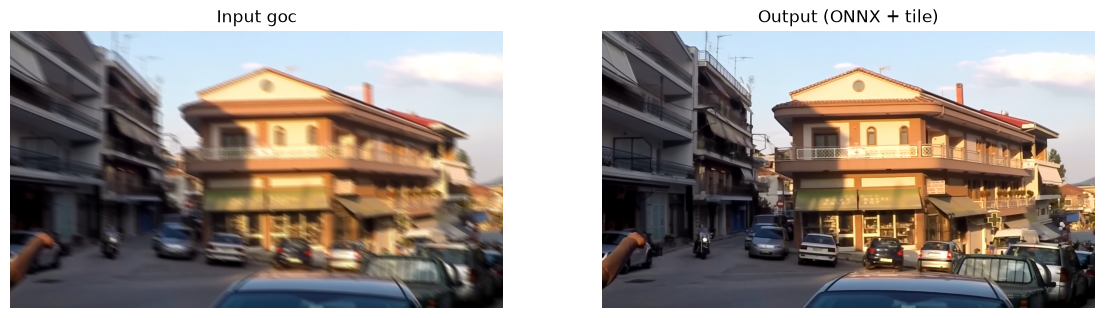

Mean abs diff input/output: 0.03500 (thang [0,1])
Da luu ket qua: ../Result/images/ket_qua_onnx_full.png
=> Model co thay doi anh. Xem tiep Buoc 6 de doi chieu voi NAFNetLocal,
   va Buoc 7 de zoom kiem tra chi tiet.


In [15]:
INPUT_IMAGE_PATH = '../Data/train/input/GOPR0372_07_00-000047.png'  # <-- doi sang anh khac neu muon, vi du anh cua ban

img_in, img_out_tile = run_tiled_inference(INPUT_IMAGE_PATH, sess, IMG_H, IMG_W)
mean_diff_tile = show_and_report(img_in, img_out_tile, 'Input goc', 'Output (ONNX + tile)')

OUTPUT_DIR = '../Result/images'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_IMAGE_PATH = f'{OUTPUT_DIR}/ket_qua_onnx_full.png'
Image.fromarray((img_out_tile * 255).astype(np.uint8)).save(OUTPUT_IMAGE_PATH)
print('Da luu ket qua:', OUTPUT_IMAGE_PATH)

if mean_diff_tile < 0.005:
    print('=> RAT GAN 0: model gan nhu khong thay doi gi anh nay ca.')
else:
    print('=> Model co thay doi anh. Xem tiep Buoc 6 de doi chieu voi NAFNetLocal,')
    print('   va Buoc 7 de zoom kiem tra chi tiet.')

## Buoc 6. Phep thu quyet dinh: NAFNetLocal (PyTorch thuan, KHONG tile, KHONG ONNX)

- Neu cach nay cho ket qua net ro ret hon han Buoc 5 -> viec bo TLC + cat tile
  (danh doi de chay duoc tren mobile) la nguyen nhan giam chat luong.
- Neu CUNG cho ket qua yeu tuong tu -> nghi van chuyen sang checkpoint `.pth`.

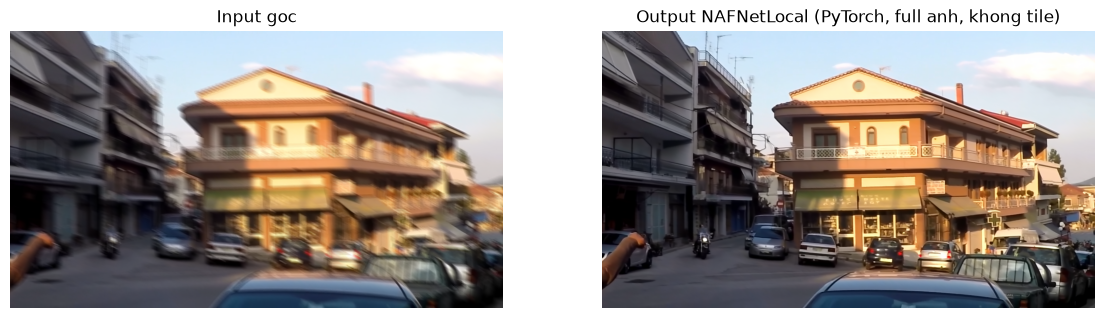

Mean abs diff input/output: 0.03536 (thang [0,1])

So sanh truc tiep tren cung anh:
  ONNX + tile      : mean abs diff = 0.03500
  NAFNetLocal full  : mean abs diff = 0.03536
=> Hai cach tuong tu nhau -> xem tiep Buoc 7 (zoom) truoc khi ket luan.


In [16]:
out_local_np = run_local_full(img_in, model_local)
mean_diff_local = show_and_report(
    img_in, out_local_np,
    'Input goc', 'Output NAFNetLocal (PyTorch, full anh, khong tile)'
)

print(f'\nSo sanh truc tiep tren cung anh:')
print(f'  ONNX + tile      : mean abs diff = {mean_diff_tile:.5f}')
print(f'  NAFNetLocal full  : mean abs diff = {mean_diff_local:.5f}')
if mean_diff_local > mean_diff_tile * 1.5:
    print('=> NAFNetLocal cai thien ro ret hon -> bo TLC + cat tile la nguyen nhan giam chat luong.')
else:
    print('=> Hai cach tuong tu nhau -> xem tiep Buoc 7 (zoom) truoc khi ket luan.')

## Buoc 7. Zoom vao 1 vung cu the de danh gia dung

`mean_abs_diff` tren toan anh lon de bi hieu nham la "gan 0" khi thuc ra van
co cai thien that, chi la kho thay khi anh bi thu nho de hien thi canh nhau.

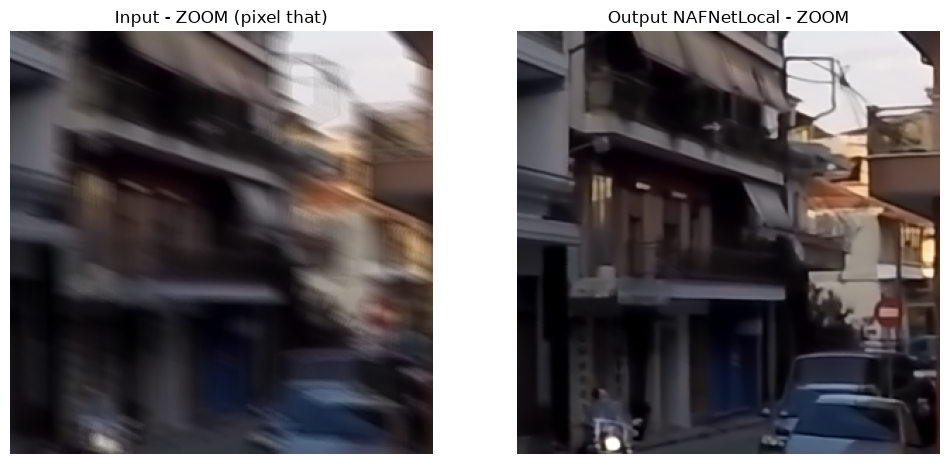

Neu zoom van khong thay khac biet ro ret o vien/canh -> model that su khong cai thien duoc anh nay.
Neu zoom thay net hon ro ret -> van de chi do hien thi anh full-size bi thu nho, khong phai loi ky thuat.


In [17]:
# Chinh CROP_Y, CROP_X, CROP_SIZE cho trung vung bi mo manh nhat trong anh dang test
CROP_Y, CROP_X, CROP_SIZE = 250, 200, 300  # <-- chinh lai cho khop anh dang test

crop_in = img_in[CROP_Y:CROP_Y+CROP_SIZE, CROP_X:CROP_X+CROP_SIZE, :]
crop_out = out_local_np[CROP_Y:CROP_Y+CROP_SIZE, CROP_X:CROP_X+CROP_SIZE, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(crop_in); axes[0].set_title('Input - ZOOM (pixel that)'); axes[0].axis('off')
axes[1].imshow(crop_out); axes[1].set_title('Output NAFNetLocal - ZOOM'); axes[1].axis('off')
plt.show()

print('Neu zoom van khong thay khac biet ro ret o vien/canh -> model that su khong cai thien duoc anh nay.')
print('Neu zoom thay net hon ro ret -> van de chi do hien thi anh full-size bi thu nho, khong phai loi ky thuat.')

## Buoc 8. Test bang bo du lieu test chinh thuc (lmdb)

Cach test cong bang nhat: dung dung anh + dung do phan giai ma paper dung de
bao cao PSNR/SSIM. Dung san `input.lmdb` va `target.lmdb` da co trong `../Data/`.

In [19]:
LMDB_DIR = '../Data/input.lmdb'
TARGET_LMDB_DIR = '../Data/target.lmdb'

if not (os.path.exists(LMDB_DIR) and os.path.exists(TARGET_LMDB_DIR)):
    print(f'Chua tim thay lmdb test set trong {LMDB_DIR} / {TARGET_LMDB_DIR} — bo qua buoc nay.')
    print('(Tai ve theo huong dan trong docs/GoPro.md neu muon danh gia PSNR/SSIM chinh thuc.)')
else:
    import lmdb
    import cv2
    from basicsr.metrics.psnr_ssim import calculate_psnr, calculate_ssim

    N_SAMPLES = None
    meta_info_path = os.path.join(LMDB_DIR, 'meta_info.txt')
    with open(meta_info_path, 'r') as f:
        keys = [line.split('.png')[0] + '.png' for line in f.readlines()]
    sample_keys = keys[:N_SAMPLES]
    print(f'Danh gia tren {len(sample_keys)} / {len(keys)} anh cua tap test...')

    def decode_lmdb_image(env, key):
        lmdb_key = key.rsplit('.', 1)[0]  # lmdb luu key khong co duoi file (vd: 'GOPR0384_11_00-000001')
        with env.begin(write=False) as txn:
            buf = txn.get(lmdb_key.encode('ascii'))
        bgr = cv2.imdecode(np.frombuffer(buf, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb.astype(np.float32) / 255.0

    def tile_infer_array(img_np, sess, img_h, img_w):
        h, w = img_np.shape[:2]
        pad_h, pad_w = (-h) % img_h, (-w) % img_w
        img_padded = np.pad(img_np, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        H_pad, W_pad = img_padded.shape[:2]
        out_padded = np.zeros_like(img_padded)
        for i in range(H_pad // img_h):
            for j in range(W_pad // img_w):
                y0, y1 = i * img_h, (i + 1) * img_h
                x0, x1 = j * img_w, (j + 1) * img_w
                tile_in = img_padded[y0:y1, x0:x1, :].transpose(2, 0, 1)[None].astype(np.float32)
                tile_out = sess.run(None, {'input': tile_in})[0]
                out_padded[y0:y1, x0:x1, :] = tile_out[0].transpose(1, 2, 0)
        return np.clip(out_padded[:h, :w, :], 0, 1)

    env_in = lmdb.open(LMDB_DIR, readonly=True, lock=False, readahead=False)
    env_gt = lmdb.open(TARGET_LMDB_DIR, readonly=True, lock=False, readahead=False)

    psnr_input_list, ssim_input_list = [], []
    psnr_tile_list, ssim_tile_list = [], []

    for idx, key in enumerate(sample_keys):
        img_in_np = decode_lmdb_image(env_in, key)
        img_gt_np = decode_lmdb_image(env_gt, key)
        out_tile_np = tile_infer_array(img_in_np, sess, IMG_H, IMG_W)

        psnr_input_list.append(calculate_psnr(img_in_np, img_gt_np, crop_border=0))
        psnr_tile_list.append(calculate_psnr(out_tile_np, img_gt_np, crop_border=0))
        ssim_input_list.append(calculate_ssim(img_in_np, img_gt_np, crop_border=0))
        ssim_tile_list.append(calculate_ssim(out_tile_np, img_gt_np, crop_border=0))
        print(f'[{idx+1}/{len(sample_keys)}] {key}: PSNR input={psnr_input_list[-1]:.2f} tile={psnr_tile_list[-1]:.2f}')

    env_in.close(); env_gt.close()

    print(f'\n=== KET QUA TRUNG BINH tren {len(sample_keys)} anh ===')
    print(f'Input (chua xu ly) : PSNR = {np.mean(psnr_input_list):.2f} dB | SSIM = {np.mean(ssim_input_list):.4f}')
    print(f'ONNX + tile        : PSNR = {np.mean(psnr_tile_list):.2f} dB | SSIM = {np.mean(ssim_tile_list):.4f}')
    print(f'\n(De so sanh: paper bao cao NAFNet-GoPro-width64 dat trung binh ~33.71 dB tren toan bo {len(keys)} anh test.)')

Danh gia tren 1111 / 1111 anh cua tap test...
[1/1111] GOPR0384_11_00-000001.png: PSNR input=24.05 tile=33.89
[2/1111] GOPR0384_11_00-000002.png: PSNR input=24.60 tile=33.72
[3/1111] GOPR0384_11_00-000003.png: PSNR input=25.50 tile=34.60
[4/1111] GOPR0384_11_00-000004.png: PSNR input=25.42 tile=29.85
[5/1111] GOPR0384_11_00-000005.png: PSNR input=26.96 tile=35.54
[6/1111] GOPR0384_11_00-000006.png: PSNR input=26.79 tile=35.11
[7/1111] GOPR0384_11_00-000007.png: PSNR input=30.27 tile=36.52
[8/1111] GOPR0384_11_00-000008.png: PSNR input=26.83 tile=35.56
[9/1111] GOPR0384_11_00-000009.png: PSNR input=30.51 tile=37.10
[10/1111] GOPR0384_11_00-000010.png: PSNR input=31.47 tile=36.97
[11/1111] GOPR0384_11_00-000011.png: PSNR input=27.90 tile=35.75
[12/1111] GOPR0384_11_00-000012.png: PSNR input=28.32 tile=34.94
[13/1111] GOPR0384_11_00-000013.png: PSNR input=24.87 tile=34.01
[14/1111] GOPR0384_11_00-000014.png: PSNR input=23.58 tile=32.75
[15/1111] GOPR0384_11_00-000015.png: PSNR input=23.56